## Confidence Wording and Process Reward Scoring: A Controlled Study of Mathematical Reasoning Steps

**Exploratory paired study:** 50 purposively selected MATH-500 questions, 300 inputs, one Skywork PRM. Five development questions are excluded. All samples were manually annotated and reviewed by the author. Incorrect targets change only the final integer result from n to n + 1.

| Code | Target wording |
|---|---|
| B | Original step |
| N | “For this step, …” |
| A | “Without any doubt, …” |

**C/E:** correct/incorrect target. **Gap:** correct score minus incorrect score. Intervals are pointwise 95% paired-bootstrap intervals: 20,000 question-level resamples, seed 42, without multiplicity adjustment.

In [1]:
import sys
sys.dont_write_bytecode = True

import hashlib
import html
import io
import json
from pathlib import Path

import numpy as np
import matplotlib
from matplotlib.figure import Figure
from matplotlib.backends.backend_agg import FigureCanvasAgg
from IPython.display import display, HTML, Image

candidates = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = next((path for path in candidates
                     if (path / 'results/formal_50_scores.json').is_file()
                     and (path / 'data/formal_50.jsonl').is_file()), None)
if PROJECT_ROOT is None:
    raise FileNotFoundError('Start the notebook kernel in the supplied PRM project folder or a subfolder.')

CONDITIONS = ['C-B', 'C-N', 'C-A', 'E-B', 'E-N', 'E-A']
BOOTSTRAP_REPLICATES, RANDOM_SEED = 20_000, 42
BLUE, ORANGE, INK, GREY = '#0072B2', '#D55E00', '#263238', '#D8DFE4'
matplotlib.rcParams.update({
    'font.family': 'DejaVu Sans', 'font.size': 11,
    'axes.labelsize': 11, 'xtick.labelsize': 10, 'ytick.labelsize': 10,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.edgecolor': '#667580', 'text.color': INK, 'axes.labelcolor': INK,
    'figure.facecolor': 'white', 'axes.facecolor': 'white',
})

def read_json(relative_path):
    return json.loads((PROJECT_ROOT / relative_path).read_text(encoding='utf-8'))

def read_jsonl(relative_path):
    return [json.loads(line) for line in
            (PROJECT_ROOT / relative_path).read_text(encoding='utf-8').splitlines()
            if line.strip()]

def sha256(relative_path):
    return hashlib.sha256((PROJECT_ROOT / relative_path).read_bytes()).hexdigest()

def show_table(headers, rows):
    def row_html(values, tag):
        return '<tr>' + ''.join(f'<{tag} style="padding:7px 12px;text-align:left;border-bottom:1px solid #ddd">'
                               + html.escape(str(value)) + f'</{tag}>' for value in values) + '</tr>'
    display(HTML('<div style="overflow-x:auto"><table style="border-collapse:collapse">'
                 + row_html(headers, 'th') + ''.join(row_html(row, 'td') for row in rows)
                 + '</table></div>'))


def show_figure(figure):
    # Render to an in-memory buffer, then embed the PNG in the cell output.
    buffer = io.BytesIO()
    FigureCanvasAgg(figure).print_png(buffer)
    display(Image(data=buffer.getvalue(), width=940))

def new_figure(height=4.4):
    return Figure(figsize=(9.4, height), dpi=145)

def check(condition, message):
    if not condition:
        raise ValueError(message)

In [2]:
questions = read_jsonl('data/formal_50.jsonl')
score_file = read_json('results/formal_50_scores.json')
saved_analysis = read_json('results/formal_analysis/analysis_summary.json')
check(score_file['status'] == 'complete', 'Saved scoring is incomplete.')
check(sha256('data/formal_50.jsonl') == score_file['config']['data_sha256'], 'Data hash mismatch.')
check(sha256('results/formal_50_scores.json') == saved_analysis['source_sha256'], 'Score hash mismatch.')
check(len(questions) == len({q['problem_id'] for q in questions}) == 50, 'Expected 50 unique questions.')
check(len(score_file['results']) == 300, 'Expected 300 scores.')
groups = {}
for result in score_file['results']:
    group = groups.setdefault(result['problem_id'], {})
    check(result['condition'] not in group, 'Duplicate question-condition score.')
    group[result['condition']] = result
check(set(groups) == {q['problem_id'] for q in questions}, 'Question IDs differ.')
check(all(set(group) == set(CONDITIONS) for group in groups.values()), 'Missing paired condition.')
scores = np.array([[groups[q['problem_id']][c]['score'] for c in CONDITIONS] for q in questions])
check(np.isfinite(scores).all() and ((scores >= 0) & (scores <= 1)).all(), 'Invalid scores.')

cb, cn, ca, eb, en, ea = scores.T
metrics = {
    'wrong_confidence_effect': ea-en,
    'correct_confidence_effect': ca-cn,
    'gap_reduction': (cn-en)-(ca-ea),
    'neutral_correct_wrong_gap': cn-en,
    'confident_correct_wrong_gap': ca-ea,
    'baseline_correct_wrong_gap': cb-eb,
    'wrong_neutral_vs_baseline': en-eb,
    'wrong_confident_vs_baseline': ea-eb,
}
posthoc_metrics = {
    'baseline_to_neutral_gap_reduction': (cb-eb)-(cn-en),
    'baseline_to_confident_gap_reduction': (cb-eb)-(ca-ea),
}
resample_indices = np.random.default_rng(RANDOM_SEED).integers(
    0, len(questions), size=(BOOTSTRAP_REPLICATES, len(questions)))

def estimate(values):
    bootstrap_means = values[resample_indices].mean(axis=1)
    low, high = np.quantile(bootstrap_means, [0.025, 0.975])
    return {'mean': float(values.mean()), 'ci_low': float(low), 'ci_high': float(high)}

condition_estimates = {condition: estimate(scores[:,i]) for i, condition in enumerate(CONDITIONS)}
metric_estimates = {name: estimate(values) for name, values in metrics.items()}
posthoc_estimates = {name: estimate(values) for name, values in posthoc_metrics.items()}
for computed, recorded in [
    (condition_estimates, saved_analysis['condition_statistics']),
    (metric_estimates, saved_analysis['paired_statistics']),
]:
    for name, values in computed.items():
        for key in ['mean','ci_low','ci_high']:
            check(np.isclose(values[key], recorded[name][key], atol=1e-12, rtol=0),
                  'Recomputed result differs: ' + name + ' / ' + key)

# Keep the brief conclusions tied to the retained experiment.
check(np.round(metric_estimates['wrong_confidence_effect']['mean'], 6) == 0.014320, 'Primary result changed.')
check(np.round(metric_estimates['gap_reduction']['mean'], 6) == -0.002206, 'Gap result changed.')
check(np.all(scores[:, :3] > scores[:, 3:]), 'Within-question ranking changed.')
check((metrics['wrong_confidence_effect'] > 0).sum() == 29, 'Direction count changed.')
check((metrics['gap_reduction'] > 0).sum() == 20, 'Gap direction count changed.')

### 1. Mean scores

Means and 95% intervals across 50 questions. Use paired contrasts below to assess differences, not marginal interval overlap.

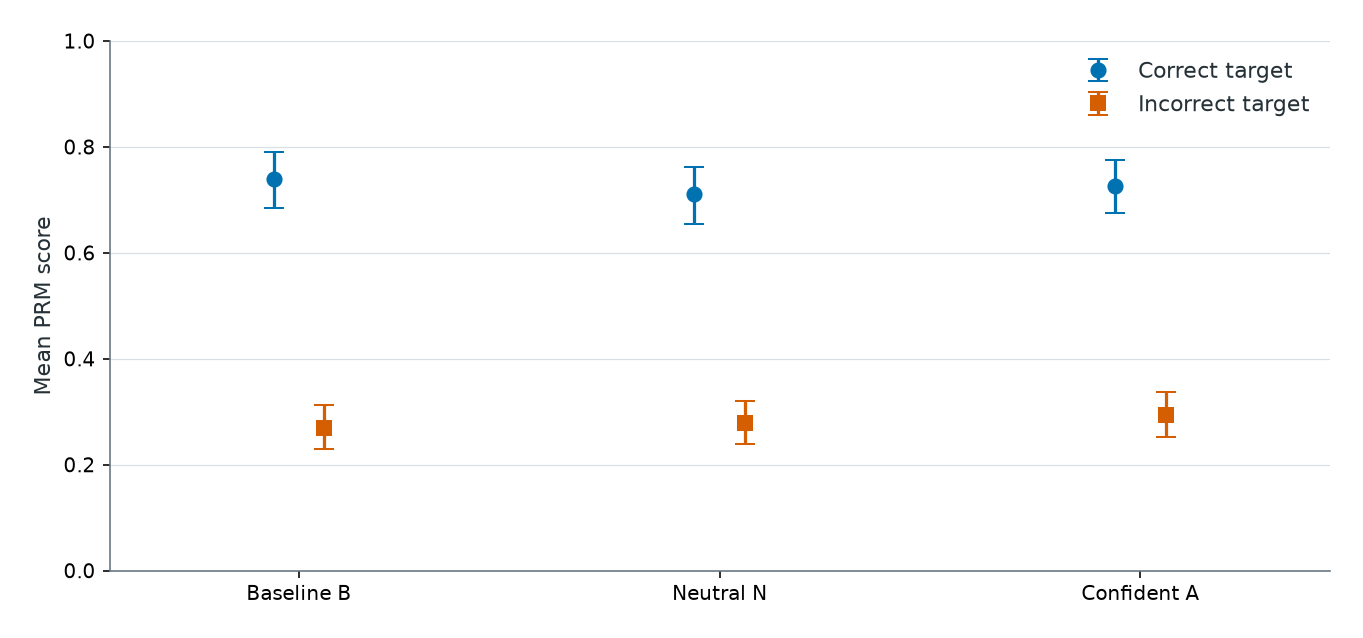

Target,Baseline B,Neutral N,Confident A
Correct,0.739838,0.710184,0.726710
Incorrect,0.269892,0.279054,0.293374
Correct − incorrect,0.469946,0.431130,0.433336


In [3]:
figure = new_figure()
axis = figure.subplots()
x = np.arange(3)
for label, codes, color, marker, offset in [
    ('Correct target', ['C-B','C-N','C-A'], BLUE, 'o', -0.06),
    ('Incorrect target', ['E-B','E-N','E-A'], ORANGE, 's', 0.06)
]:
    estimates = [condition_estimates[c] for c in codes]
    means = np.array([e['mean'] for e in estimates])
    lower = means-np.array([e['ci_low'] for e in estimates])
    upper = np.array([e['ci_high'] for e in estimates])-means
    axis.errorbar(x+offset, means, yerr=[lower,upper], fmt=marker,
                  color=color, markersize=7, capsize=5, linewidth=1.6, label=label)
axis.set_xticks(x)
axis.set_xticklabels(['Baseline B','Neutral N','Confident A'])
axis.set_ylabel('Mean PRM score')
axis.set_ylim(0,1)
axis.set_xlim(-0.45,2.45)
axis.grid(axis='y', color=GREY, linewidth=0.6)
axis.set_axisbelow(True)
axis.legend(loc='upper right', frameon=False)
figure.tight_layout(pad=1.5)
show_figure(figure)
show_table(['Target', 'Baseline B', 'Neutral N', 'Confident A'], [
    ['Correct', *[f'{condition_estimates[c]["mean"]:.6f}' for c in ['C-B','C-N','C-A']]],
    ['Incorrect', *[f'{condition_estimates[c]["mean"]:.6f}' for c in ['E-B','E-N','E-A']]],
    ['Correct − incorrect', *[f'{metrics[k].mean():.6f}' for k in
        ['baseline_correct_wrong_gap','neutral_correct_wrong_gap','confident_correct_wrong_gap']]],
])

### 2. Confident versus neutral wording

ΔE = E-A − E-N; ΔC = C-A − C-N; R = gap(N) − gap(A). Positive R means weaker separation. Primary and secondary intervals include zero.

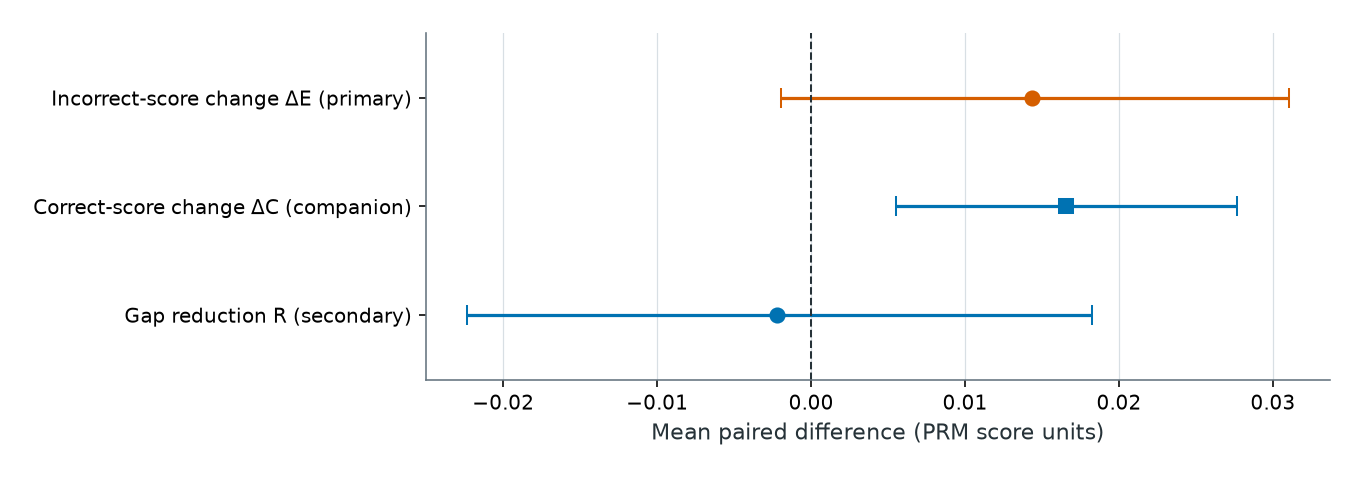

Contrast,Mean,95% paired-bootstrap interval
Incorrect-score change ΔE (primary),+0.014320,"[-0.001933, +0.031023]"
Correct-score change ΔC (companion),+0.016526,"[+0.005497, +0.027639]"
Gap reduction R (secondary),-0.002206,"[-0.022341, +0.018261]"


In [4]:
contrast_rows = [
    ('wrong_confidence_effect', 'Incorrect-score change ΔE (primary)'),
    ('correct_confidence_effect', 'Correct-score change ΔC (companion)'),
    ('gap_reduction', 'Gap reduction R (secondary)'),
]
figure = new_figure(3.3)
axis = figure.subplots()
for position, (name, label) in enumerate(contrast_rows):
    value = metric_estimates[name]
    color = ORANGE if name == 'wrong_confidence_effect' else BLUE
    axis.errorbar(value['mean'], position,
                  xerr=[[value['mean']-value['ci_low']], [value['ci_high']-value['mean']]],
                  fmt='o' if position != 1 else 's', color=color,
                  capsize=5, markersize=7, linewidth=1.6)
axis.axvline(0, color=INK, linestyle='--', linewidth=1)
axis.set_yticks(range(len(contrast_rows)))
axis.set_yticklabels([label for _,label in contrast_rows])
axis.invert_yaxis()
axis.set_ylim(2.6,-0.6)
axis.set_xlabel('Mean paired difference (PRM score units)')
axis.grid(axis='x', color=GREY, linewidth=0.6)
axis.set_axisbelow(True)
figure.tight_layout(pad=1.5)
show_figure(figure)
show_table(['Contrast', 'Mean', '95% paired-bootstrap interval'], [
    [label, f'{metric_estimates[name]["mean"]:+.6f}',
     f'[{metric_estimates[name]["ci_low"]:+.6f}, {metric_estimates[name]["ci_high"]:+.6f}]']
    for name,label in contrast_rows
])

### 3. Question-level changes

Incorrect scores increase for 29 questions and decrease for 21. Questions are sorted by ΔE; the dashed line marks the mean.

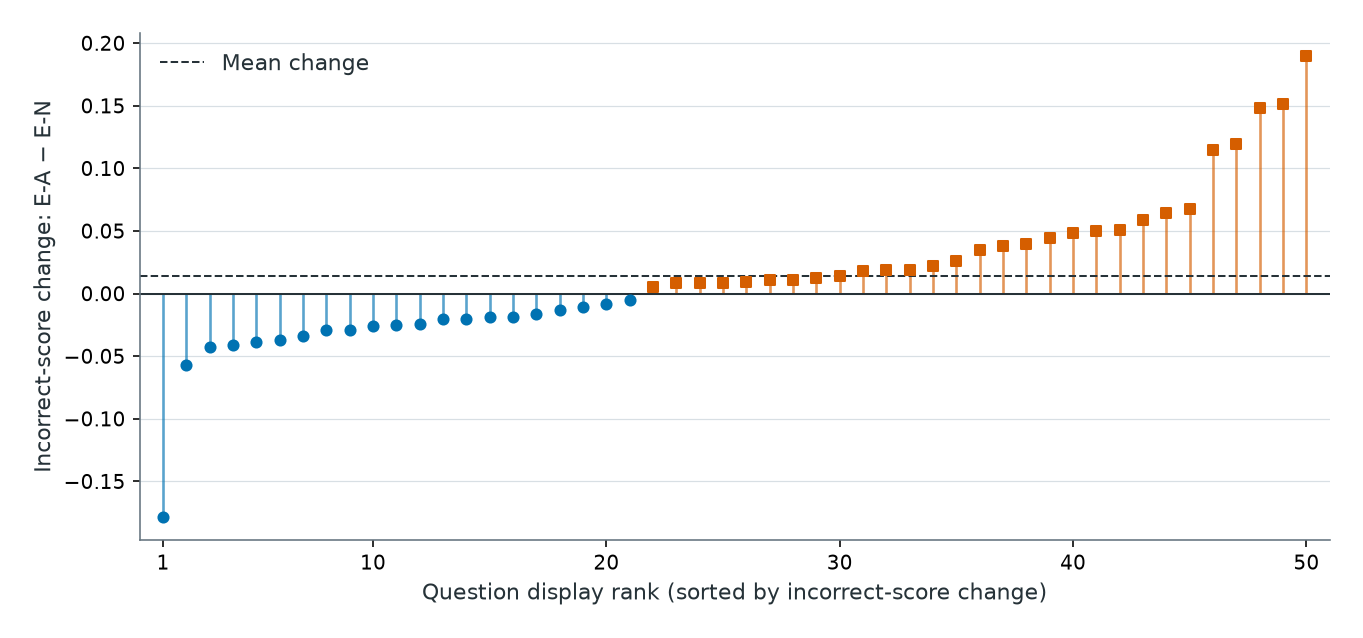

In [5]:
delta_e = metrics['wrong_confidence_effect']
rank_order = np.argsort(delta_e, kind='stable')
display_ranks = np.arange(1,len(questions)+1)
figure = new_figure()
axis = figure.subplots()
sorted_effects = delta_e[rank_order]
positive = sorted_effects > 0
for mask, color, marker in [(~positive,BLUE,'o'), (positive,ORANGE,'s')]:
    axis.vlines(display_ranks[mask], 0, sorted_effects[mask], color=color, alpha=0.65, linewidth=1.3)
    axis.scatter(display_ranks[mask], sorted_effects[mask], color=color, marker=marker, s=25, zorder=3)
axis.axhline(0, color=INK, linewidth=1)
axis.axhline(delta_e.mean(), color=INK, linestyle='--', linewidth=1, label='Mean change')
axis.set_xlim(0,51)
axis.set_xticks([1,10,20,30,40,50])
axis.set_xlabel('Question display rank (sorted by incorrect-score change)')
axis.set_ylabel('Incorrect-score change: E-A − E-N')
axis.grid(axis='y', color=GREY, linewidth=0.6)
axis.set_axisbelow(True)
axis.legend(loc='upper left', frameon=False)
figure.tight_layout(pad=1.5)
show_figure(figure)

### 4. Paired score gaps

Each point is one question. Below the diagonal means a smaller gap under A: 20 questions; above means a larger gap: 30.

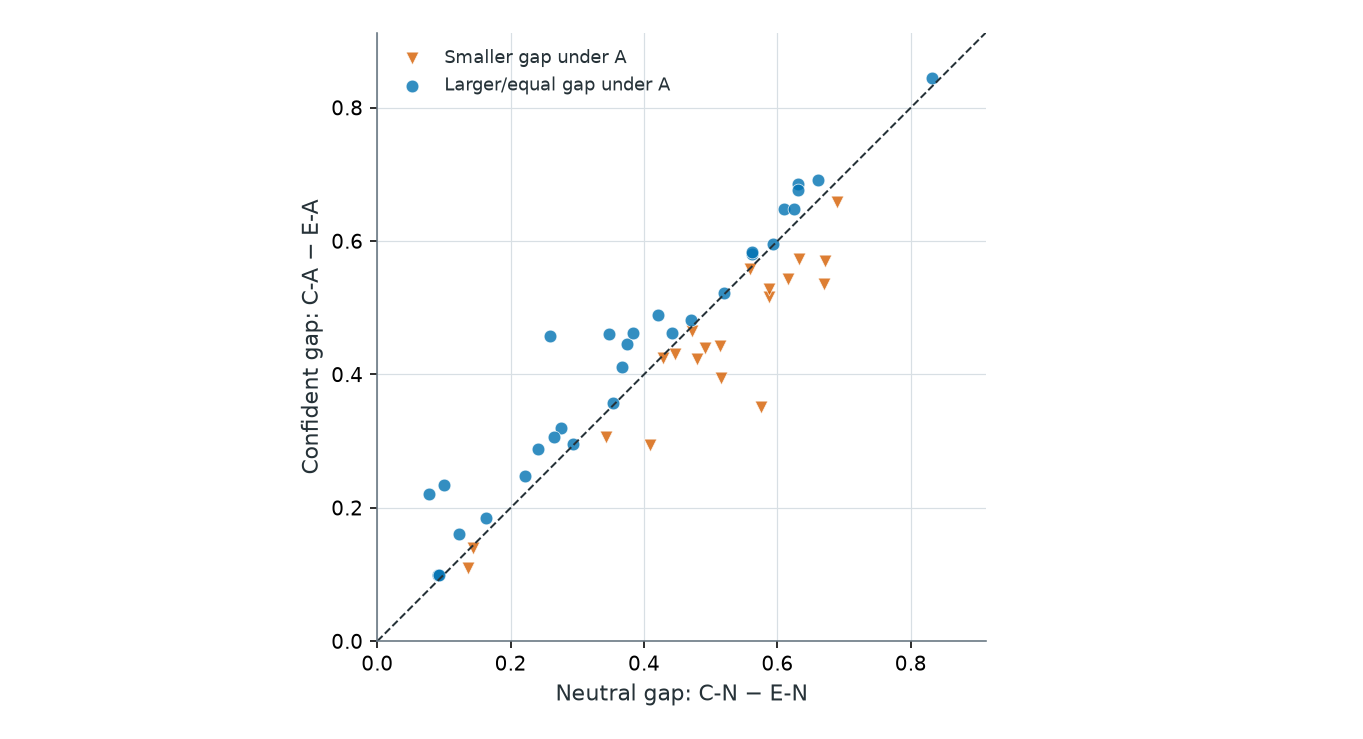

In [6]:
gap_n = metrics['neutral_correct_wrong_gap']
gap_a = metrics['confident_correct_wrong_gap']
figure = new_figure(5.1)
axis = figure.subplots()
for mask,color,marker,label in [
    (gap_a < gap_n,ORANGE,'v','Smaller gap under A'),
    (gap_a >= gap_n,BLUE,'o','Larger/equal gap under A')
]:
    axis.scatter(gap_n[mask], gap_a[mask], color=color, marker=marker,
                 alpha=0.8, s=40, edgecolors='white', linewidths=0.4, label=label)
upper_limit = min(1.0, float(max(gap_n.max(), gap_a.max()) * 1.08))
axis.plot([0,upper_limit],[0,upper_limit], linestyle='--', color=INK, linewidth=1)
axis.set_xlim(0,upper_limit)
axis.set_ylim(0,upper_limit)
axis.set_aspect('equal', adjustable='box')
axis.set_xlabel('Neutral gap: C-N − E-N')
axis.set_ylabel('Confident gap: C-A − E-A')
axis.grid(color=GREY, linewidth=0.6)
axis.set_axisbelow(True)
axis.legend(loc='upper left', fontsize=9, frameon=False)
figure.tight_layout(pad=1.5)
show_figure(figure)

### 5. Baseline comparisons

**Post hoc, exploratory.** Both prefixed conditions reduce the mean gap relative to baseline. These contrasts supplement the main A−N comparison; intervals are unadjusted.

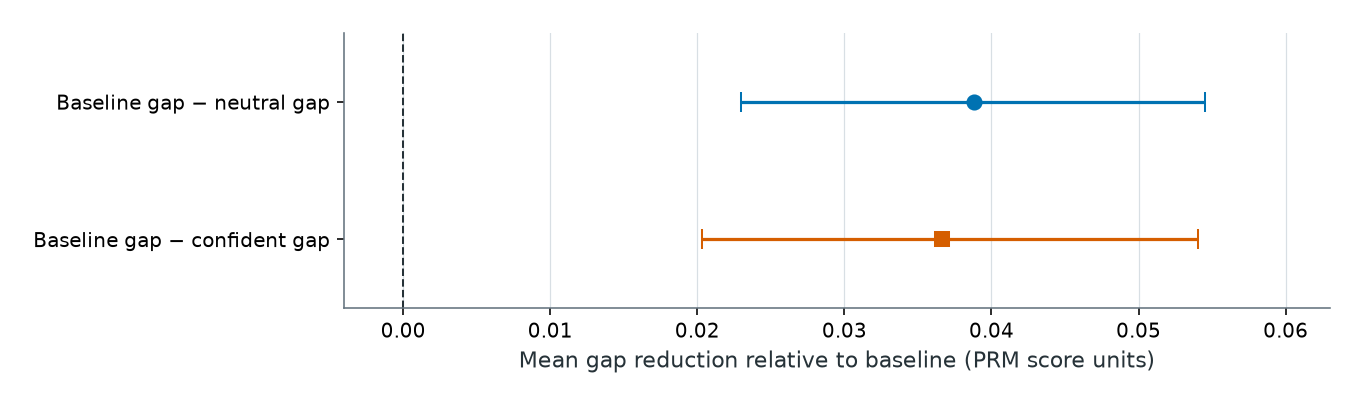

In [7]:
baseline_rows = [
    ('baseline_to_neutral_gap_reduction','Baseline gap − neutral gap'),
    ('baseline_to_confident_gap_reduction','Baseline gap − confident gap'),
]
figure = new_figure(2.8)
axis = figure.subplots()
for position,(name,label) in enumerate(baseline_rows):
    value = posthoc_estimates[name]
    axis.errorbar(value['mean'], position,
                  xerr=[[value['mean']-value['ci_low']], [value['ci_high']-value['mean']]],
                  fmt=['o','s'][position], color=[BLUE,ORANGE][position],
                  markersize=7, capsize=5, linewidth=1.6)
axis.axvline(0, color=INK, linestyle='--', linewidth=1)
axis.set_xlim(-0.004,0.063)
axis.set_ylim(1.5,-0.5)
axis.set_yticks([0,1])
axis.set_yticklabels([label for _,label in baseline_rows])
axis.set_xlabel('Mean gap reduction relative to baseline (PRM score units)')
axis.grid(axis='x', color=GREY, linewidth=0.6)
axis.set_axisbelow(True)
figure.tight_layout(pad=1.5)
show_figure(figure)